# Chapter 3 — Cornering the cause

Chapter 2 named the wild double and showed it is a *symptom*. This chapter is the elimination round.
Every **fixable** explanation for the agreement gap gets the same treatment — settling, learning-order,
capacity, coverage, reward variance, and the standard knobs — and each is ruled out as *the* cause. The
shape is deliberately repetitive: **hypothesis → test → verdict → keeper**. None of these experiments is
wasted: each leaves a *usable method* or a *clean fact* behind even when it fails to close the gap. The
cumulative force of one independent null after another is what finally pins the cause on representation
(Chapter 4).

What counts as a "keeper" is decided by data, not story. Three leave a usable method — a stable schedule (3.1), a curriculum (3.2), and a network sized to the rules (3.3) — though, read honestly, their value is stability and parsimony, not a clear gain on the agreement metric: none of the three closes the cap, and each verdict says so. The other three leave only a clean fact (3.4 coverage, 3.5 reward variance, 3.6 the knobs) — interesting nulls, each ruling a suspect out. Every table below carries its source, and where an effect is confounded we say so rather than claim it.

## 3.1 Settling — the learning-rate schedule

The wild double is constant-gain variance (Ch2), so the textbook fix is to **decay the step**. It works —
the double settles — but a *single global* step size faces a **reach-vs-settle frontier**: low enough to
settle the terminal double, high enough to learn the rest of the map, and it cannot be both at once. Three
runs trace it.

In [1]:
import sys; sys.path.insert(0, '.')
import statistics as st
import pandas as pd
import matplotlib.pyplot as plt
from runs import load_runs, learning_curve, show, provenance, fignote

df = load_runs(); dqn = df[df.method == 'dqn']; d = dqn[~dqn.with_splits]

constant = d[(d.lr_schedule=='constant') & (d.encoding=='scalar') & (d.episodes==1_500_000)]
settle   = d[(d.lr_schedule=='harmonic') & (d.lr_end==1e-5) & (d.episodes==1_500_000) & (d.lr_hold_until==0) & (d.encoding=='scalar')]
reach    = d[(d.lr_schedule=='linear') & (d.episodes==1_500_000) & (d.batch==128) & (d.reward_baseline=='stand') & (d.encoding=='scalar')]

def stats(label, g):
    return {'schedule': label, 'agreement': g.agreement.mean(), 'edge': g.edge_pct.mean(), 'double-std': g.soft20_double_std.mean()}
frontier = pd.DataFrame([
    stats('constant lr (oscillates)',     constant),
    stats('harmonic→1e-5 (settle hard)',  settle),
    stats('linear→0 (reach)',             reach),
])
show(frontier, pct=['agreement'], num=['edge', 'double-std'],
     caption='The reach-vs-settle frontier. Push the step down (harmonic→1e-5) and the double settles '
             '(double-std 0.16) but agreement under-learns; keep it up (linear) and agreement reaches highest '
             'but the double stays noisy. A single global rate cannot do both.',
     source='source: scalar · 1.5M ep · seed 42 — constant & harmonic single runs; linear = mean over %d runs' % len(reach))

schedule,agreement,edge,double-std
constant lr (oscillates),82.9%,1.40,0.32
harmonic→1e-5 (settle hard),81.2%,1.85,0.16
linear→0 (reach),89.3%,1.09,0.32


**The lever is the lr, not the schedule's name.** Plot any run's back-half double-std against its
back-half *average* learning rate and the schedules collapse onto one curve: harmonic settles best only
because its 1/k tail makes the back-half lr lowest. So "which schedule" is the wrong question; "how low is
the step while the double learns" is the right one. The endpoint numbers hide this — every value is a
snapshot of a quantity still moving — so the agreement-over-training view makes the frontier legible.

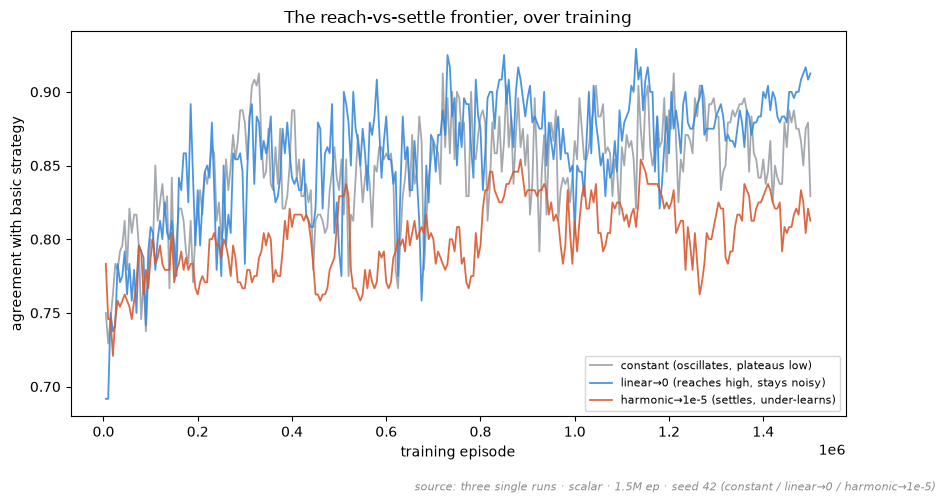

In [2]:
def agreement_curve(path):
    return [(cp['episode'], cp['agreement']) for cp in learning_curve(path) if cp.get('agreement') is not None]

curves = [('constant (oscillates, plateaus low)', constant.iloc[0], '#9AA0A6'),
          ('linear→0 (reaches high, stays noisy)', reach.iloc[0],    '#378ADD'),
          ('harmonic→1e-5 (settles, under-learns)', settle.iloc[0],  '#D85A30')]
fig, ax = plt.subplots(figsize=(10, 5))
for label, row, col in curves:
    c = agreement_curve(row.path)
    ax.plot([e for e, _ in c], [a for _, a in c], color=col, lw=1.3, alpha=0.9, label=label)
ax.set_xlabel('training episode'); ax.set_ylabel('agreement with basic strategy')
ax.set_title('The reach-vs-settle frontier, over training')
ax.legend(fontsize=8, loc='lower right')
fignote('source: three single runs · scalar · 1.5M ep · seed 42 (constant / linear→0 / harmonic→1e-5)')
plt.show()

**Verdict — a symptom, not the cause.** Decaying the step settles the double, which is a real *variance*
fix and gives us a keeper (a converging schedule). But the best-reaching run on this axis (linear) still
trails the table, and pushing the step lower to settle the double *costs* agreement. We can beat the
oscillation and the cap barely moves — because the residual is a **bias** (a wrong action in a few boundary
cells), and no amount of variance reduction moves a bias. The frontier is the problem; Section 3.2 takes
the *settle* route deliberately — a curriculum — and the data says it buys stability, not a higher ceiling.

## 3.2 Learning-order — the curriculum (flat-then-decay)

If one global rate can't serve both needs, separate them **in time**. Hold the step high while only
hit/stand exists — the double *masked* (`--double-after`) — then decay once the double is introduced
(`--lr-hold-until`). The schedule is co-designed with a curriculum: learn the easy map first on a stable
base, then add the noisy terminal action and quiet it down. This is the most stable configuration in the
field — but read the numbers carefully, because the win is **stability, not score**.

One thing to read correctly in the trajectory below: while the double is masked (before episode 500k) the
agent simply *cannot* double, yet basic strategy doubles in **39 of the 240 cells (16%)** — so every one
of those is forced wrong and agreement is **structurally capped at ~84%** during that phase. The flat low
stretch is that ceiling, not a stalled learner. Once the double unmasks at 500k the agent has to learn the
noisy new action from scratch, so there is a brief **dip** before the climb as those 39 cells come online
— not a clean step up.

config,agreement,edge,double-std
flat-then-decay (curriculum),87.1%,1.21,0.12
"linear→0 (best reacher, 3.1)",89.3%,1.09,0.32


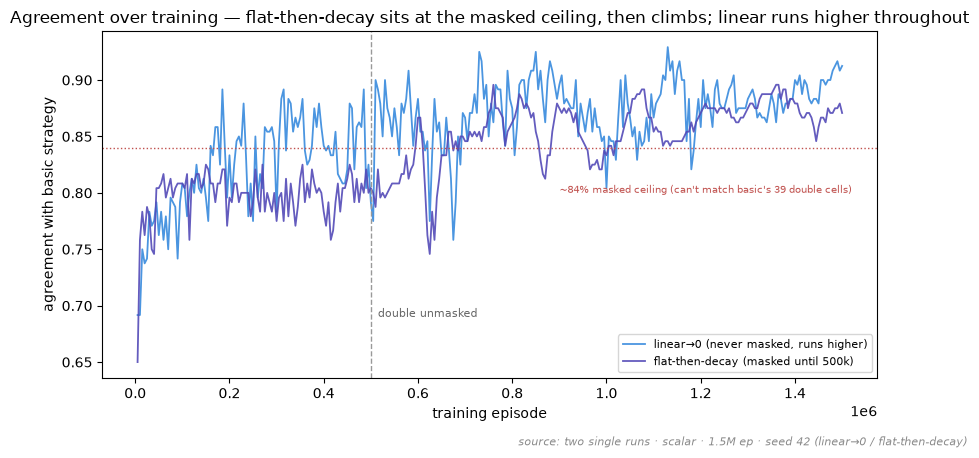

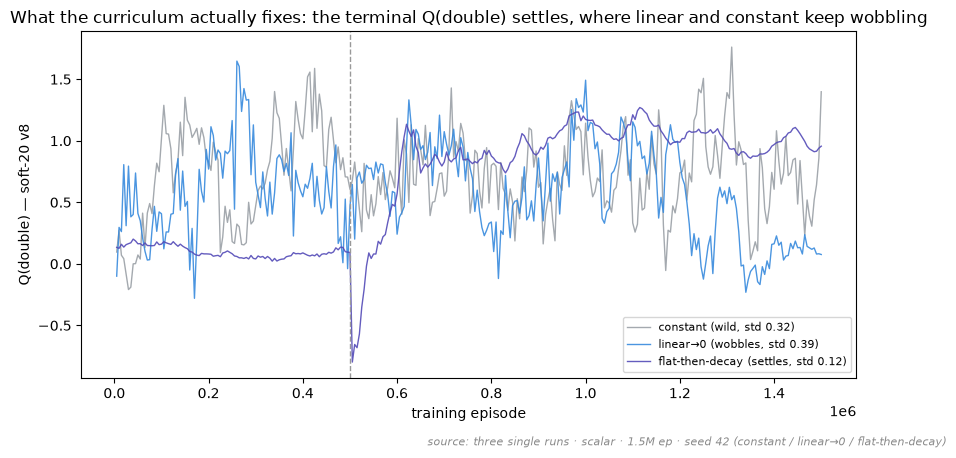

In [3]:
ftd = d[(d.lr_hold_until>0) & (d.encoding=='scalar') & (d.episodes==1_500_000)]
comp = pd.DataFrame([
    {'config': 'flat-then-decay (curriculum)', 'agreement': ftd.agreement.mean(),  'edge': ftd.edge_pct.mean(),  'double-std': ftd.soft20_double_std.mean()},
    {'config': 'linear→0 (best reacher, 3.1)', 'agreement': reach.agreement.mean(), 'edge': reach.edge_pct.mean(), 'double-std': reach.soft20_double_std.mean()},
])
show(comp, pct=['agreement'], num=['edge', 'double-std'],
     caption='Flat-then-decay settles the double TIGHTEST of anything (double-std 0.12 vs 0.32) — and still '
             'trails linear on agreement (87.1% vs 89.3%). The curriculum buys stability, not a higher ceiling.',
     source='source: scalar · 1.5M ep · seed 42 — flat-then-decay single run; linear = mean over %d runs' % len(reach))

# Figure 1 — agreement over training, read honestly: the masked ceiling, then a dip-then-climb; linear runs higher throughout.
fig, ax = plt.subplots(figsize=(10, 4.5))
for label, row, col in [('linear→0 (never masked, runs higher)',  reach.iloc[0], '#378ADD'),
                        ('flat-then-decay (masked until 500k)',   ftd.iloc[0],   '#534AB7')]:
    c = agreement_curve(row.path)
    ax.plot([e for e, _ in c], [a for _, a in c], color=col, lw=1.3, alpha=0.9, label=label)
ax.axvline(500_000, ls='--', color='#999', lw=1); ax.text(515_000, 0.69, 'double unmasked', fontsize=8, color='#666')
ax.axhline(0.84, ls=':', color='#C0504D', lw=1)
ax.text(900000, 0.80, "~84% masked ceiling (can't match basic's 39 double cells)", fontsize=7.5, color='#C0504D')
ax.set_xlabel('training episode'); ax.set_ylabel('agreement with basic strategy')
ax.set_title('Agreement over training — flat-then-decay sits at the masked ceiling, then climbs; linear runs higher throughout')
ax.legend(fontsize=8, loc='lower right')
fignote('source: two single runs · scalar · 1.5M ep · seed 42 (linear→0 / flat-then-decay)')
plt.show()

# Figure 2 — the keeper, made visible: the terminal Q(double) SETTLES under the curriculum, where the others wobble.
def qd(path):
    return [(cp['episode'], cp['probe_q']['soft20_v8']['double'])
            for cp in learning_curve(path) if cp.get('probe_q') and 'soft20_v8' in cp.get('probe_q', {})]
fig, ax = plt.subplots(figsize=(10, 4.5))
for label, row, col in [('constant (wild, std 0.32)',     constant.iloc[0], '#9AA0A6'),
                        ('linear→0 (wobbles, std 0.39)',   reach.iloc[0],    '#378ADD'),
                        ('flat-then-decay (settles, std 0.12)', ftd.iloc[0], '#534AB7')]:
    q = qd(row.path)
    ax.plot([e for e, _ in q], [v for _, v in q], color=col, lw=1.0, alpha=0.9, label=label)
ax.axvline(500_000, ls='--', color='#999', lw=1)
ax.set_xlabel('training episode'); ax.set_ylabel('Q(double) — soft-20 v8')
ax.set_title('What the curriculum actually fixes: the terminal Q(double) settles, where linear and constant keep wobbling')
ax.legend(fontsize=8, loc='lower right')
fignote('source: three single runs · scalar · 1.5M ep · seed 42 (constant / linear→0 / flat-then-decay)')
plt.show()

**Verdict — keeper: a stable platform, not a higher cap.** Honest accounting: curriculum never varies
*alone* in our runs (it is always bundled with the decay-after step — flat-then-decay is one intervention),
so we do not claim it independently lifts agreement; the data says it doesn't (linear scores higher). What
it *does*, cleanly and repeatably, is settle the double tightest in the field and give the smoothest
trajectory. That stability is the keeper — it is the platform the *rest of this chapter* is measured on,
because a wobbling baseline would drown every other effect in seed noise. A real method whose value is
legibility, not score.

## 3.3 Capacity — is the network the wrong size?

Two opposite worries: maybe the net is too *small* to represent the decision map, or maybe it needs more
neurons than we gave it. A rule-count prior says small should be plenty — basic strategy is a *compact
rule set* (a few dozen threshold rules; adjacent cells share an action), and a ReLU layer needs only about
one boundary unit per rule. We check it two ways: a **matched sweep** where only the width changes, and the
**full width range** in the naive regime.

In [4]:
# --- A) matched sweep: only the network width changes (good stack, 1.5M) ---
sweep = d[(d.encoding=='onehot') & (d.lr_schedule=='harmonic') & (d.episodes==1_500_000)
          & (d.reward_baseline=='stand') & (d.double_after==500_000) & (d.double_dqn) & (d.seed==42)]
order = {'[8, 8]':0, '[16, 16]':1, '[64, 64]':2}
sz = (sweep[sweep.hidden.isin(order)].assign(o=lambda x: x.hidden.map(order)).sort_values('o')
      .groupby('hidden', sort=False)
      .agg(agreement=('agreement','mean'), edge=('edge_pct','mean'), **{'double-std':('soft20_double_std','mean')})
      .reset_index().rename(columns={'hidden':'network'}))
show(sz, pct=['agreement'], num=['edge', 'double-std'],
     caption='Matched sweep — only the width changes (good stack, 1.5M). [8,8] underfits; [16,16] (32 neurons) '
             'and [64,64] are a near dead heat (89.6% vs 90.0%). Thirty-two neurons already capture the map; '
             'four-times-wider adds nothing here.',
     source='source: onehot · harmonic 1e-3→1e-5 · stand-baseline · double@500k · Double-DQN · 1.5M ep · seed 42 — one run per size')

# --- B) the full width range in the naive regime (one canonical config) ---
import ast
naive = ((d.encoding=='scalar') & (d.lr_schedule=='constant') & (d.episodes==1_000_000) & (d.lr==1e-3)
         & (d.target_sync_every==1000) & (~d.double_dqn) & (~d.exploring_starts) & (d.train_every==4)
         & (d.reward_baseline=='none') & (d.double_after==0) & (d.target_tau==0) & (~d.swa))
big = d[naive & d.hidden.isin(['[8, 8]','[16, 16]','[32, 32]','[64, 64]','[64, 64, 64]','[128, 128]','[256, 256]'])].copy()
big['neurons'] = big.hidden.map(lambda h: sum(ast.literal_eval(h)))
bz = (big.sort_values('neurons').groupby(['hidden','neurons'], sort=False)
      .agg(n=('agreement','size'), agreement=('agreement','mean'), edge=('edge_pct','mean'),
           **{'double-std':('soft20_double_std','mean')}).reset_index().rename(columns={'hidden':'network'}))
b = big[big.hidden=='[64, 64]']
show(bz, pct=['agreement'], num=['edge', 'double-std'],
     caption='Full width range, naive regime (one canonical config; [64,64] run 3× across seeds). [64,64] alone '
             'spans %.1f–%.1f%% agreement across seeds — a ~%.0f-pt band that covers every size from [16,16] up; '
             '[8,8] underfits below it. Run-to-run noise, not width, sets these differences.'
             % (100*b.agreement.min(), 100*b.agreement.max(), 100*(b.agreement.max()-b.agreement.min())),
     source='source: scalar · constant lr 1e-3 · target_sync 1000 · 1M ep — [64,64] = 3 seeds (42–44); other sizes single runs (seed 42)')
print('edge carries the same seed noise: [64,64] over 3 seeds spans %.2f–%.2f%% (~%.2f pp), so the cross-size edge gaps sit inside the band too.'
      % (b.edge_pct.min(), b.edge_pct.max(), b.edge_pct.max()-b.edge_pct.min()))

network,agreement,edge,double-std
"[8, 8]",87.1%,1.41,0.11
"[16, 16]",89.6%,1.23,0.06
"[64, 64]",90.0%,1.12,0.06


network,neurons,n,agreement,edge,double-std
"[8, 8]",16,1,72.9%,2.99,0.24
"[16, 16]",32,1,80.4%,2.49,0.67
"[32, 32]",64,1,82.5%,1.76,0.43
"[64, 64]",128,3,81.3%,2.10,0.47
"[64, 64, 64]",192,1,79.2%,1.94,0.52
"[128, 128]",256,1,82.9%,1.53,0.44
"[256, 256]",512,1,80.0%,1.67,0.63


edge carries the same seed noise: [64,64] over 3 seeds spans 1.66–2.72% (~1.07 pp), so the cross-size edge gaps sit inside the band too.


**Verdict — bigger isn't simply the answer; [16,16] fits the rule set.** At the budgets and seeds we have,
more width past [16,16] does not buy a clear, repeatable gain — the cross-size differences sit *inside* the
seed band on both agreement and edge. The one consistent signal is the other direction: **[8,8] (16 neurons)
is too small** — it underfits in both regimes. So the sensible reading isn't "go bigger," it's **size the
net to the problem**. Basic strategy is a few-dozen-rule map and a ReLU layer needs roughly one boundary
unit per rule, so **[16,16] = 32 neurons** is a natural fit: small enough to be cheap, comfortably past
[8,8]'s underfit. Capacity is not the binding cap.

What we do *not* claim: that [16,16] is uniquely optimal, or that width never matters at any budget. The
longer [64,64] runs keep inching up with more training (back-half 88.4% → 89.5% → 91.1% across 1.5 / 2.5 /
5M), so the bigger net clearly has *headroom* extended training can use — we just lack matched [16,16] runs
at those lengths to say whether the small net would track it, so we leave that open (Chapter 5 takes up
training length directly). The load-bearing point here is the modest one: the function is small, a small
net sized to the rules is the right tool, and "just make it bigger" is not the lesson.

## 3.4 Coverage — exploring starts

Maybe the boundary cells are simply *starved*: once the greedy policy commits and ε anneals, rare cells
stop getting fresh data and drift. The fix is **exploring starts** — force every (state, action) to be a
start state, so no cell can be under-sampled. If coverage were the cap, forcing it should clear the
residual. It doesn't.

In [5]:
# matched pair at the LONGEST exploring-starts budget we have (1.5M, good stack), not 1M: does forcing
# (state,action) coverage clear the residual? es ON vs OFF, everything else identical.
base = ((d.encoding=='scalar') & (d.hidden=='[64, 64]') & (d.lr_schedule=='linear') & (d.reward_baseline=='stand')
        & (d.double_dqn) & (d.episodes==1_500_000) & (d.batch==128) & (d.seed==42))
esT = d[base & d.exploring_starts]
esF = d[base & (~d.exploring_starts)]
def od(g):
    import json as _j; from pathlib import Path as _P
    overs = []
    for p in g.path:
        cells = _j.load(open(_P(p)/'record.json', encoding='utf-8'))['diff']['cells']
        overs.append(sum(1 for c in cells if c['category']=='genuine_disagreement'
                         and c['agent_action']=='double' and c['basic_action']!='double'))
    return st.mean(overs) if overs else float('nan')
cov = pd.DataFrame([
    {'setting': 'exploring starts ON',  'agreement': esT.agreement.mean(), 'edge': esT.edge_pct.mean(), 'over-doubles': od(esT)},
    {'setting': 'exploring starts OFF', 'agreement': esF.agreement.mean(), 'edge': esF.edge_pct.mean(), 'over-doubles': od(esF)},
])
show(cov, pct=['agreement'], num=['edge', 'over-doubles'],
     caption='Forcing uniform (state,action) coverage does NOT clear the residual — at 1.5M in the good stack it '
             'actively hurts: agreement falls (~91% → 86%), edge worsens, and the over-doubling roughly doubles '
             '(~10 → 24). Coverage is not the cap.',
     source='source: scalar · [64,64] · linear · stand-baseline · Double-DQN · 1.5M ep · seed 42 — es OFF (%d runs) vs ON (%d run)' % (len(esF), len(esT)))

# robustness across budgets + encodings: the over-double is the part that's CONSISTENT (agreement scatters
# within seed noise). Across every exploring-starts run, forced coverage keeps the over-double high — it
# never drops to the es-OFF good-stack level.
import json as _j; from pathlib import Path as _P
def _over(path):
    cells = _j.load(open(_P(path)/'record.json', encoding='utf-8'))['diff']['cells']
    return sum(1 for c in cells if c['category']=='genuine_disagreement' and c['agent_action']=='double' and c['basic_action']!='double')
all_es = sorted(_over(p) for p in d[d.exploring_starts].path)
print('over-doubles across all %d exploring-starts runs (1M+1.5M, both encodings): %s'
      % (len(all_es), all_es))
print('  median %.0f under forced coverage  vs  ~%.0f with es OFF in the good stack — coverage never clears the over-double.'
      % (st.median(all_es), od(esF)))

setting,agreement,edge,over-doubles
exploring starts ON,85.8%,1.31,24.00
exploring starts OFF,91.0%,0.95,10.00


over-doubles across all 6 exploring-starts runs (1M+1.5M, both encodings): [22, 23, 24, 24, 29, 30]
  median 24 under forced coverage  vs  ~10 with es OFF in the good stack — coverage never clears the over-double.


**Verdict — a null that rules *in* representation.** Forcing coverage doesn't help — and at the longest
budget we have (1.5M, good stack) it actively *hurts*: agreement drops ~5 points and the over-doubling
roughly doubles. The reason is telling. The network already has an answer at *every* cell (it generalizes),
so there are no starved cells to fill; meanwhile exploring starts forces extra double-heavy start states,
flooding the agent with the very high-variance `double` experience that drives the over-double bias. So
coverage is a *table* problem (a lookup table only knows the cells it visited), not a network problem —
and this null sharpens the target: the residual is in how the net *represents* the boundary, not in which
cells it saw. (Generalization-vs-coverage returns as a headline in Chapter 7.)

## 3.5 Reward variance — a dealer control variate

Every hand pays **±2**, and most of that swing is the **dealer's** luck — the same dealer outcome is shared
across hit, stand, and double, so it is *noise* with respect to which action you pick. The textbook remedy
is a **control variate**: subtract a mean-zero, action-independent estimate of the dealer's contribution
from the reward (here, the `--reward-baseline stand` flag). It is provably **unbiased** — expected value and
the optimal policy are unchanged — and in principle it should make the learning signal cleaner, especially
for the high-variance double. Does it actually help?

Two honest answers below: what the runs can (and *cannot*) tell us, and then *why* — mechanically — it
can't move the one cell that matters.

In [6]:
# (1) What a naive run comparison says — and why it is a trap.
stand = d[d.reward_baseline=='stand']; none = d[d.reward_baseline=='none']
gap = 100*(stand.agreement.mean() - none.agreement.mean())
print('Naive aggregate: stand-baseline averages %.1f%% agreement vs %.1f%% with no baseline — looks like +%.1f points.'
      % (100*stand.agreement.mean(), 100*none.agreement.mean(), gap))
print('But that gap is the STACK, not the baseline: the stand-baseline runs are ALSO the decaying-lr / curriculum /')
print('longer-trained ones. The baseline was never varied on its own, so there is no clean ablation to isolate it —')
print('and a +5-point "win" read off a correlated sweep is exactly the confound to distrust.')

# (2) Why it cannot help the cell that matters: where a doubled hand's +/-2 variance actually comes from.
import random
V = list(range(2, 11)) + [10, 10, 10] + [11]
def hv(cs):
    t, a = sum(cs), cs.count(11)
    while t > 21 and a: t -= 10; a -= 1
    return t
def dealer(up, rng):
    c = [up, rng.choice(V)]
    while hv(c) < 17: c.append(rng.choice(V))
    t = hv(c); return 0 if t > 21 else t
def rew(pf, dl): return -1.0 if pf > 21 else (1.0 if dl == 0 else (1.0 if pf > dl else (-1.0 if pf < dl else 0.0)))
def decomp(start, up, n=120_000):
    rng = random.Random(0); rows = []
    for _ in range(n):
        pf = hv(start + [rng.choice(V)]); dl = dealer(up, rng); rows.append((2*rew(pf, dl), pf, dl))
    r = [x[0] for x in rows]; var = st.pvariance(r); mu = st.mean(r)
    def expl(k):
        g = {}
        for x in rows: g.setdefault(k(x), []).append(x[0])
        return sum(len(v)*(st.mean(v)-mu)**2 for v in g.values())/len(rows)/var
    return expl(lambda x: x[2]), expl(lambda x: x[1])   # dealer-share, player-draw-share
vd = pd.DataFrame([dict(zip(['double cell', 'dealer (CV cancels this)', 'player draw (intrinsic)'],
        [n] + list(decomp(c, u)))) for n, c, u in [('soft-20 v8', [11,9], 8), ('hard-11 v6', [5,6], 6), ('hard-16 v10', [10,6], 10)]])
show(vd, pct=['dealer (CV cancels this)', 'player draw (intrinsic)'],
     caption="Where a doubled hand's ±2 variance comes from. The control variate can cancel only the DEALER "
             "column; the player-draw column is the agent's own one-card draw — intrinsic, uncancellable. On the "
             "double the dealer is the MINORITY of the variance, so the control variate leaves most of the noise standing.",
     source='source: analytic Monte-Carlo of the hand model, 120k draws/cell — not a training run')

Naive aggregate: stand-baseline averages 87.6% agreement vs 82.0% with no baseline — looks like +5.5 points.
But that gap is the STACK, not the baseline: the stand-baseline runs are ALSO the decaying-lr / curriculum /
longer-trained ones. The baseline was never varied on its own, so there is no clean ablation to isolate it —
and a +5-point "win" read off a correlated sweep is exactly the confound to distrust.


double cell,dealer (CV cancels this),player draw (intrinsic)
soft-20 v8,34.4%,41.5%
hard-11 v6,45.7%,25.5%
hard-16 v10,9.7%,62.7%


**Verdict — an honest null (a correct tool aimed at the wrong variance).** The control variate is *right*:
unbiased, EV-preserving, and it genuinely cancels the dealer's share of the noise. But that share is not
where the trouble is. The cell that actually misbehaves — the terminal double — is dominated by the
**player's own one-card draw**, which is intrinsic and which no action-independent baseline can touch. So
the technique quiets noise we did not need quieted and cannot reach the noise we did.

And because the baseline only ever ran *inside* the stack, its standalone effect can't even be measured —
the +5-point aggregate is the stack talking, not the baseline. Two takeaways, neither a keeper: a
**mechanism** (match a variance-reduction tool to the actual variance source, or it does nothing where you
need it) and a **discipline** (an effect read off a correlated sweep will mislead — trust matched
comparisons, not aggregates).

## 3.6 The standard knobs

Finally, the usual DQN add-ons — Double-DQN, batch size, weight averaging (SWA), a soft target. Each is a
reasonable idea, and a couple are mildly, consistently positive. But the decisive fact is the **seed band**:
rerun the *same* naive config at different seeds and agreement swings ~8 points on its own. Every single-knob
effect we can isolate lives *inside* that band — so no one of them closes the naive→tabular gap, and you
cannot even conclude a knob "works" from a single comparison. The recovery is the **stack**, not a lever.

In [7]:
naive_band = d[(d.encoding=='onehot') & (d.lr_schedule=='constant') & (d.episodes==1_000_000)
               & (d.reward_baseline=='none') & (d.double_after==0) & (~d.swa)]
band = 100*(naive_band.agreement.max() - naive_band.agreement.min())

CTRL = ['encoding','lr_schedule','episodes','lr','lr_end','reward_baseline','double_after','lr_hold_until','batch']
def bool_effect(knob):
    deltas=[]
    for _, g in d.groupby(CTRL, dropna=False):
        m = g.groupby(knob).agreement.mean()
        if {True, False} <= set(m.index): deltas.append(100*(m[True]-m[False]))
    return (st.mean(deltas), len(deltas)) if deltas else (float('nan'), 0)
ddqn = bool_effect('double_dqn'); swa = bool_effect('swa')
tau_on = d[d.target_tau>0].soft20_double_std.dropna().mean(); tau_off = d[(d.target_tau==0)&(d.lr_schedule=='constant')&(d.encoding=='onehot')].soft20_double_std.dropna().mean()
knobs = pd.DataFrame([
    {'knob': 'Double-DQN', 'mean Δ agreement (matched)': ddqn[0], 'within seed band?': 'yes'},
    {'knob': 'SWA (weight averaging)', 'mean Δ agreement (matched)': swa[0], 'within seed band?': 'yes'},
])
show(knobs, num=['mean Δ agreement (matched)'],
     caption='Matched single-knob effects on agreement (averaged over every context where only that knob '
             'varies). Both are mildly positive on average (the table shows each) and both fit inside the '
             '%.0f-point seed band — so neither alone closes the gap.' % band,
     source='source: all no-split DQN runs, matched within-config pairs (Double-DQN: %d contexts, SWA: %d)' % (ddqn[1], swa[1]))
print('seed band (same naive config, seeds %s): %.1f points — as large as the best single-knob effect'
      % (sorted(set(naive_band.seed.dropna())), band))
print('soft target (tau): double-std %.2f on vs %.2f off — inert (Ch2), not a knob worth turning' % (tau_on, tau_off))
print('batch size: mixed across contexts (64→512 helped once +6pts, 128→512 hurt once −2.5pts) — inside the band')

knob,mean Δ agreement (matched),within seed band?
Double-DQN,1.63,yes
SWA (weight averaging),3.61,yes


seed band (same naive config, seeds [42, 43, 44]): 8.3 points — as large as the best single-knob effect
soft target (tau): double-std 0.65 on vs 0.77 off — inert (Ch2), not a knob worth turning
batch size: mixed across contexts (64→512 helped once +6pts, 128→512 hurt once −2.5pts) — inside the band


## 3.7 Conclusion — six suspects, six verdicts

Settling, learning-order, capacity, coverage, reward variance, the standard knobs: every fixable,
training-side explanation tested and ruled out as *the* cause. Three left a real method — a converging
schedule, a curriculum that buys stability, and a right-sized [16,16] network — and three left a clean fact:
coverage doesn't bind a model that generalizes, the control variate is inert on the intrinsic-variance
double, and no single knob escapes the seed band. Through every one of them the residual keeps the **same
fingerprint**: over-doubling, one direction, concentrated in a handful of low-margin boundary cells. That
is the signature of a **bias**, not variance, under-training, or starvation — and a bias in specific cells
is a property of how the function approximator *represents* the decision map. Chapter 4 looks straight at
that representation, and finds the errors exactly where it predicts.